# Cross-Asset Latent State & Market Shock Detection

### An anonymized, leakage-aware revision of the original seminar prototype

이 노트북은 기존 세미나 프로토타입의 두 아이디어를 유지하면서 연구 설계를 다시 구성한다.

1. **여러 금융자산의 시계열을 latent representation으로 압축하고 KOSPI의 다음 시점 수익률을 예측한다.**
2. **자산 간 latent synchronization과 latent displacement를 이용해 시장 충격 신호를 정의하고 OOS에서 검증한다.**

핵심 원칙은 다음과 같다.

- 예측 시점보다 미래 정보는 입력에 사용하지 않는다.
- 정규화, 임계값, PCA 등 데이터 기반 변환은 train 구간에서만 학습한다.
- 금융 시계열의 level 복원이 아니라 **다음 시점 return forecasting**으로 문제를 명확히 정의한다.
- latent 변수는 해석 가능성을 과장하지 않고, 예측력과 충격 탐지력으로 검증한다.
- 개인 이름, 학력, 연락처, 계정 정보 등 개인정보는 포함하지 않는다.

> 이 노트북은 연구/교육용 실험이며 투자 판단을 위한 매수·매도 신호를 제공하는 것이 목적이 아니다.

## 1. 무엇을 고쳤는가

| 기존 프로토타입 | 문제 | 개선안 |
|---|---|---|
| 60일 KOSPI 구간을 입력하고 그 구간 마지막 KOSPI 값을 예측 | 자기복원에 가까워 미래 예측 성능으로 보기 어려움 | `t`까지의 정보로 `t+1` KOSPI **수익률** 예측 |
| 전체 기간에 `MinMaxScaler.fit` | 미래 분포가 train에 유입될 수 있음 | scaler는 **train-only fit** |
| 전체 표본으로 학습 후 같은 표본에서 그림 확인 | in-sample 적합도와 OOS 성능 혼동 | chronological train / validation / test |
| level 중심 학습 | 비정상성 및 단순 추세 추종 위험 | log return / yield difference 중심 |
| 모든 데이터를 한 번에 full-batch 학습 | 일반화·메모리·검증 측면 취약 | mini-batch + early stopping + gradient clipping |
| 서로 독립적으로 학습한 AE latent의 dot product | latent 좌표계가 정렬되어 있지 않아 내적의 의미가 불안정 | **shared encoder**로 공통 latent space 구성 + cosine similarity |
| 전체 표본의 92/95% quantile을 collision threshold로 사용 | 미래 데이터로 threshold 결정 | train 구간 quantile만 사용 |
| 시각적 결과 위주 | 우연한 패턴인지 판별 어려움 | baseline, OOS metric, shock label, AUROC/F1, ablation |
| PCA/attention을 곧바로 경제적 인과로 해석 | 설명 과잉 위험 | representation/association으로 제한해 해석 |

특히 두 번째 실험에서 **독립적으로 학습한 Autoencoder 두 개의 latent vector를 직접 내적하는 것**은 가장 먼저 수정해야 할 부분이다. Autoencoder의 latent 축은 회전·순열·스케일 변환에 대해 식별되지 않을 수 있으므로, 서로 다른 모델에서 나온 좌표를 그대로 비교하면 숫자의 의미가 불안정하다. 이 노트북은 모든 자산 window에 같은 encoder를 적용한다.

## 2. 환경 설정

In [1]:
# Google Colab 기준. 이미 설치되어 있으면 빠르게 종료됩니다.
%pip -q install yfinance

In [2]:
from dataclasses import dataclass
from copy import deepcopy
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings('ignore', category=FutureWarning)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


@dataclass
class Config:
    start_date: str = '2015-01-02'
    # yfinance의 end는 exclusive. 2026-08-18까지를 고정 스냅샷으로 사용.
    end_date: str = '2026-08-19'

    seq_len: int = 60
    shock_window: int = 20

    train_ratio: float = 0.70
    val_ratio: float = 0.15

    batch_size: int = 128
    hidden_size: int = 48
    latent_size: int = 32

    epochs: int = 80
    patience: int = 10
    lr: float = 1e-3
    weight_decay: float = 1e-4

    ae_hidden: int = 32
    ae_latent: int = 8
    ae_epochs: int = 50
    ae_batch_size: int = 512
    ae_seeds: tuple = (11, 23, 37)

    shock_quantile: float = 0.95
    seed: int = 42


CFG = Config()
set_seed(CFG.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

device = cuda


## 3. 데이터

원래 세미나에서 사용한 7개 자산을 그대로 유지한다.

- WTI
- USD/KRW
- Gold
- S&P 500
- US 10Y Treasury Yield
- VIX
- KOSPI

다만 미국과 한국의 휴장일이 다르므로 KOSPI 거래일을 기준 달력으로 두고, 다른 시장 데이터는 **과거 값만 forward-fill**한다. `bfill`은 사용하지 않는다.

> 주의: Yahoo Finance의 daily date label은 거래소별 현지 시각을 완전히 표현하지 않는다. 엄밀한 실시간 연구에서는 각 시장 close timestamp와 한국 장 개장 시각을 기준으로 lag를 다시 정렬해야 한다.

In [3]:
ASSET_TICKERS = {
    'WTI': 'CL=F',
    'USD_KRW': 'KRW=X',
    'Gold': 'GC=F',
    'S&P500': '^GSPC',
    'US10Y': '^TNX',
    'VIX': '^VIX',
    'KOSPI': '^KS11',
}

ASSET_NAMES = list(ASSET_TICKERS.keys())
TARGET = 'KOSPI'


def _calendar_index(index) -> pd.DatetimeIndex:
    """Convert a market-specific daily index to timezone-free calendar dates."""
    idx = pd.DatetimeIndex(pd.to_datetime(index))
    if idx.tz is not None:
        # Preserve the exchange-local calendar date, then remove timezone.
        idx = idx.tz_localize(None)
    return idx.normalize()


def _extract_close(df: pd.DataFrame, ticker: str) -> pd.Series:
    if df is None or df.empty:
        raise RuntimeError(f'No data downloaded for {ticker}')

    # yfinance may return either flat columns or a MultiIndex.
    if isinstance(df.columns, pd.MultiIndex):
        lvl0 = df.columns.get_level_values(0)
        if 'Close' not in lvl0:
            raise RuntimeError(f'Close column not found for {ticker}')
        close = df['Close']
        if isinstance(close, pd.DataFrame):
            # Single-ticker downloads normally have one sub-column.
            if ticker in close.columns:
                close = close[ticker]
            else:
                close = close.iloc[:, 0]
    else:
        if 'Close' not in df.columns:
            raise RuntimeError(f'Close column not found for {ticker}')
        close = df['Close']

    s = pd.Series(
        np.asarray(close, dtype='float64').reshape(-1),
        index=_calendar_index(close.index),
        name=ticker,
        dtype='float64',
    )
    # Defensive handling for rare duplicated daily labels.
    s = s[~s.index.duplicated(keep='last')].sort_index()
    return s.replace([np.inf, -np.inf], np.nan).dropna()


def _download_one(ticker: str, cfg: Config) -> pd.Series:
    """Download one ticker with a second route if the first response is suspiciously short."""
    raw = yf.download(
        ticker,
        start=cfg.start_date,
        end=cfg.end_date,
        interval='1d',
        auto_adjust=True,
        progress=False,
        threads=False,
        ignore_tz=True,
    )
    try:
        s = _extract_close(raw, ticker)
    except RuntimeError:
        s = pd.Series(dtype='float64', name=ticker)

    # A 2015+ daily series should normally contain far more than a few hundred rows.
    # If Yahoo returns a partial response, retry through Ticker.history().
    if len(s) < 500:
        hist = yf.Ticker(ticker).history(
            start=cfg.start_date,
            end=cfg.end_date,
            interval='1d',
            auto_adjust=True,
            actions=False,
        )
        if hist is not None and not hist.empty:
            s2 = _extract_close(hist, ticker)
            if len(s2) > len(s):
                s = s2

    return s.loc[(s.index >= pd.Timestamp(cfg.start_date)) &
                 (s.index < pd.Timestamp(cfg.end_date))]


def download_market_data(cfg: Config) -> pd.DataFrame:
    series = {}
    diagnostics = []

    for name, ticker in ASSET_TICKERS.items():
        s = _download_one(ticker, cfg)
        s.name = name
        series[name] = s
        diagnostics.append({
            'asset': name,
            'ticker': ticker,
            'rows': len(s),
            'start': s.index.min().date().isoformat() if len(s) else None,
            'end': s.index.max().date().isoformat() if len(s) else None,
        })

    diagnostic_df = pd.DataFrame(diagnostics)
    print('Raw download diagnostics')
    display(diagnostic_df)

    if len(series['KOSPI']) < 500:
        raise RuntimeError(
            'KOSPI download is too short. Check the diagnostic table above; '
            'this is a Yahoo/yfinance download problem rather than an alignment problem.'
        )

    # KOSPI trading dates define the forecasting calendar.
    kospi_calendar = series['KOSPI'].index
    panel = pd.DataFrame(index=kospi_calendar)

    for name in ASSET_NAMES:
        # Reindex only after every market has been converted to timezone-free dates.
        panel[name] = series[name].reindex(kospi_calendar)

    # KOSPI itself must never be filled across a missing observation.
    # Cross-market holidays may be carried forward for at most 3 KOSPI sessions.
    other_cols = [c for c in ASSET_NAMES if c != 'KOSPI']
    panel[other_cols] = panel[other_cols].ffill(limit=3)
    panel = panel.dropna(subset=['KOSPI'])

    aligned_before_drop = len(panel)
    missing_rate = panel.isna().mean().rename('missing_rate').to_frame()
    print('\nMissing rates after calendar alignment / limited forward-fill')
    display(missing_rate)

    panel = panel.dropna()

    if len(panel) < 1000:
        short_assets = diagnostic_df.loc[diagnostic_df['rows'] < 1000, ['asset', 'ticker', 'rows']]
        raise RuntimeError(
            f'Too few aligned observations: {len(panel)} / {aligned_before_drop}. '
            f'Assets with <1000 raw observations: {short_assets.to_dict("records")}. '
            'Inspect the diagnostic table above before continuing.'
        )

    return panel.astype('float64')


prices = download_market_data(CFG)
print('\nAligned market panel:', prices.shape)
display(prices.tail())


Raw download diagnostics


,asset,ticker,rows,start,end
0,WTI,CL=F,2923,2015-01-02,2026-08-18
1,USD_KRW,KRW=X,3025,2015-01-02,2026-08-18
2,Gold,GC=F,2922,2015-01-02,2026-08-18
3,S&P500,^GSPC,2923,2015-01-02,2026-08-18
4,US10Y,^TNX,2922,2015-01-02,2026-08-18
5,VIX,^VIX,2924,2015-01-02,2026-08-18
6,KOSPI,^KS11,2849,2015-01-02,2026-08-18



Missing rates after calendar alignment / limited forward-fill


,missing_rate
WTI,0.0
USD_KRW,0.0
Gold,0.0
S&P500,0.0
US10Y,0.0
VIX,0.0
KOSPI,0.0



Aligned market panel: (2849, 7)


,WTI,USD_KRW,Gold,S&P500,US10Y,VIX,KOSPI
Date,,,,,,,
2026-08-11,83.199997,1417.310059,4383.000000,7728.200195,4.684,15.28,6345.529785
2026-08-12,83.269997,1412.180054,4408.899902,7748.500000,4.682,14.55,6579.040039
2026-08-13,81.250000,1416.459961,4363.600098,7798.990234,4.641,14.63,6813.339844
2026-08-14,82.400002,1416.849976,4380.399902,7785.759766,4.696,14.25,6977.939941
2026-08-18,84.940002,1414.729980,4366.000000,7691.759766,4.706,15.84,6869.830078


## 4. 금융 시계열 변환

가격 level을 직접 예측하면 장기 추세를 따라가는 것만으로도 그림이 좋아 보일 수 있다. 여기서는 다음 변환을 사용한다.

- 양수 가격/지수/환율: `log(P_t) - log(P_{t-1})`
- WTI: 2020년처럼 0 이하 가격이 나타날 수 있으므로 단순 1일 차분
- 미국 10년물 금리: 단순 1일 차분

예측 target은 **다음 KOSPI 거래일의 log return**이다.

In [4]:
TRANSFORM = {
    'WTI': 'diff',
    'USD_KRW': 'log_return',
    'Gold': 'log_return',
    'S&P500': 'log_return',
    'US10Y': 'diff',
    'VIX': 'log_return',
    'KOSPI': 'log_return',
}


def make_features(price_df: pd.DataFrame) -> pd.DataFrame:
    out = {}
    for col in price_df.columns:
        x = price_df[col].astype(float)
        if TRANSFORM[col] == 'log_return':
            if (x <= 0).any():
                raise ValueError(f'{col} contains non-positive values; log return invalid.')
            out[col] = np.log(x).diff()
        elif TRANSFORM[col] == 'diff':
            out[col] = x.diff()
        else:
            raise ValueError(TRANSFORM[col])

    feat = pd.DataFrame(out, index=price_df.index).replace([np.inf, -np.inf], np.nan).dropna()
    return feat


features = make_features(prices)
print(features.shape)
display((features.describe().T[['mean', 'std', 'min', 'max']]))

(2848, 7)


,mean,std,min,max
WTI,0.011324,2.277674,-55.900002,47.640001
USD_KRW,0.000090,0.005875,-0.042948,0.025392
Gold,0.000458,0.010626,-0.120657,0.074940
S&P500,0.000463,0.011267,-0.127652,0.090895
US10Y,0.000907,0.053884,-0.322000,0.269000
VIX,-0.000041,0.081186,-0.442449,0.768245
KOSPI,0.000446,0.014193,-0.128489,0.164764


## 5. Chronological split + train-only scaling

In [5]:
def chronological_split_dates(index: pd.DatetimeIndex, train_ratio: float, val_ratio: float):
    n = len(index)
    train_end_i = int(n * train_ratio) - 1
    val_end_i = int(n * (train_ratio + val_ratio)) - 1
    if not (100 < train_end_i < val_end_i < n - 100):
        raise ValueError('Split leaves too little data in one of the partitions.')
    return index[train_end_i], index[val_end_i]


TRAIN_END, VAL_END = chronological_split_dates(
    features.index, CFG.train_ratio, CFG.val_ratio
)

train_rows = features.loc[:TRAIN_END]
scaler = StandardScaler()
scaler.fit(train_rows.values)  # train only

features_z = pd.DataFrame(
    scaler.transform(features.values),
    index=features.index,
    columns=features.columns,
)

TARGET_IDX = list(features.columns).index(TARGET)
TARGET_MEAN = scaler.mean_[TARGET_IDX]
TARGET_STD = scaler.scale_[TARGET_IDX]

print('TRAIN_END =', TRAIN_END.date())
print('VAL_END   =', VAL_END.date())
print('TEST      =', (VAL_END + pd.Timedelta(days=1)).date(), '~', features.index[-1].date())

TRAIN_END = 2023-02-13
VAL_END   = 2024-11-12
TEST      = 2024-11-13 ~ 2026-08-18


## 6. 예측 문제 정의

각 표본은 다음과 같이 만든다.

\[
X_t = [x_{t-L+1}, \ldots, x_t], \qquad y_t = r^{KOSPI}_{t+1}
\]

즉 **window의 마지막 날짜 `t`보다 하루 뒤 KOSPI 수익률**만 target으로 사용한다. 이 한 줄이 기존 자기복원 문제를 제거하는 핵심이다.

In [6]:
def make_forecast_sequences(zdf: pd.DataFrame, raw_feat: pd.DataFrame, seq_len: int):
    X, y_z, y_raw, input_end_dates, target_dates = [], [], [], [], []
    target_i = zdf.columns.get_loc(TARGET)

    for end_i in range(seq_len - 1, len(zdf) - 1):
        start_i = end_i - seq_len + 1
        X.append(zdf.iloc[start_i:end_i + 1].values.astype('float32'))
        y_z.append(float(zdf.iloc[end_i + 1, target_i]))
        y_raw.append(float(raw_feat.iloc[end_i + 1, target_i]))
        input_end_dates.append(zdf.index[end_i])
        target_dates.append(zdf.index[end_i + 1])

    return (
        np.asarray(X, dtype='float32'),
        np.asarray(y_z, dtype='float32'),
        np.asarray(y_raw, dtype='float32'),
        pd.DatetimeIndex(input_end_dates),
        pd.DatetimeIndex(target_dates),
    )


X_all, y_all_z, y_all_raw, input_end_dates, target_dates = make_forecast_sequences(
    features_z, features, CFG.seq_len
)

train_mask = target_dates <= TRAIN_END
val_mask = (target_dates > TRAIN_END) & (target_dates <= VAL_END)
test_mask = target_dates > VAL_END


def take(mask):
    return X_all[mask], y_all_z[mask], y_all_raw[mask], target_dates[mask]

X_train, y_train, y_train_raw, d_train = take(train_mask)
X_val, y_val, y_val_raw, d_val = take(val_mask)
X_test, y_test, y_test_raw, d_test = take(test_mask)

print('train:', X_train.shape, len(d_train))
print('val  :', X_val.shape, len(d_val))
print('test :', X_test.shape, len(d_test))

assert d_train.max() <= TRAIN_END
assert d_val.min() > TRAIN_END and d_val.max() <= VAL_END
assert d_test.min() > VAL_END
assert np.isfinite(X_train).all() and np.isfinite(y_train).all()

train: (1933, 60, 7) 1933
val  : (427, 60, 7) 427
test : (428, 60, 7) 428


## 7. Baseline부터 확인

딥러닝 모델의 성능은 반드시 단순한 기준과 비교한다.

- **Zero Return**: 다음 수익률을 0으로 예측
- **AR-Ridge**: 최근 KOSPI 수익률만 사용
- **Cross-Asset Ridge**: 60일 × 7자산 window를 펼쳐 선형 예측

금융수익률은 잡음이 크므로 복잡한 모델이 이 baseline을 안정적으로 못 이기면 latent representation 자체가 흥미롭더라도 예측 모델로서의 주장은 약하게 해야 한다.

In [7]:
def inverse_target(z):
    return np.asarray(z) * TARGET_STD + TARGET_MEAN


def safe_corr(a, b):
    a, b = np.asarray(a), np.asarray(b)
    if len(a) < 3 or np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def forecast_metrics(y_true_raw, y_pred_raw, name):
    y_true_raw = np.asarray(y_true_raw)
    y_pred_raw = np.asarray(y_pred_raw)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_true_raw, y_pred_raw),
        'RMSE': mean_squared_error(y_true_raw, y_pred_raw) ** 0.5,
        'R2': r2_score(y_true_raw, y_pred_raw),
        'Directional_Accuracy': np.mean(np.sign(y_true_raw) == np.sign(y_pred_raw)),
        'IC_Pearson': safe_corr(y_true_raw, y_pred_raw),
    }


# 1) Zero-return baseline
pred_zero = np.zeros_like(y_test_raw)

# 2) KOSPI 자체의 최근 10개 lag만 사용하는 Ridge
kospi_i = list(features_z.columns).index(TARGET)
lag_n = min(10, CFG.seq_len)
Xtr_ar = X_train[:, -lag_n:, kospi_i]
Xte_ar = X_test[:, -lag_n:, kospi_i]

ar_model = Ridge(alpha=10.0)
ar_model.fit(Xtr_ar, y_train)
pred_ar_raw = inverse_target(ar_model.predict(Xte_ar))

# 3) 전체 cross-asset window Ridge
ridge = Ridge(alpha=20.0)
ridge.fit(X_train.reshape(len(X_train), -1), y_train)
pred_ridge_raw = inverse_target(ridge.predict(X_test.reshape(len(X_test), -1)))

baseline_table = pd.DataFrame([
    forecast_metrics(y_test_raw, pred_zero, 'Zero Return'),
    forecast_metrics(y_test_raw, pred_ar_raw, 'AR-Ridge'),
    forecast_metrics(y_test_raw, pred_ridge_raw, 'Cross-Asset Ridge'),
])
display(baseline_table.set_index('Model').round(6))

,MAE,RMSE,R2,Directional_Accuracy,IC_Pearson
Model,,,,,
Zero Return,0.016992,0.026697,-0.007998,0.000000,NaN
AR-Ridge,0.017074,0.027040,-0.034086,0.511682,-0.063389
Cross-Asset Ridge,0.017809,0.026548,0.003254,0.528037,0.203146


## 8. Multi-Asset Latent Forecaster

In [8]:
class AssetGRUEncoder(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.gru = nn.GRU(1, hidden_size, batch_first=True)
        self.norm = nn.LayerNorm(hidden_size)

    def forward(self, x):
        _, h = self.gru(x)
        return self.norm(h[-1])


class MultiAssetLatentForecaster(nn.Module):
    def __init__(self, n_assets: int, hidden_size: int, latent_size: int):
        super().__init__()
        self.n_assets = n_assets
        self.encoders = nn.ModuleList([
            AssetGRUEncoder(hidden_size) for _ in range(n_assets)
        ])

        # 각 asset representation에 공통 scoring function을 적용한다.
        self.asset_score = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1),
        )

        self.to_latent = nn.Sequential(
            nn.Linear(hidden_size, latent_size),
            nn.Tanh(),
            nn.LayerNorm(latent_size),
        )
        self.head = nn.Linear(latent_size, 1)

    def forward(self, x):
        # x: [batch, time, asset]
        reps = []
        for i, enc in enumerate(self.encoders):
            reps.append(enc(x[:, :, i:i+1]))
        reps = torch.stack(reps, dim=1)  # [B, A, H]

        logits = self.asset_score(reps).squeeze(-1)  # [B, A]
        weights = torch.softmax(logits, dim=1)
        fused = torch.sum(reps * weights.unsqueeze(-1), dim=1)

        latent = self.to_latent(fused)
        pred = self.head(latent).squeeze(-1)
        return pred, latent, weights, reps

epoch=001 train=0.48001 val=0.51150
epoch=010 train=0.44042 val=0.50217
early stopping at epoch 13


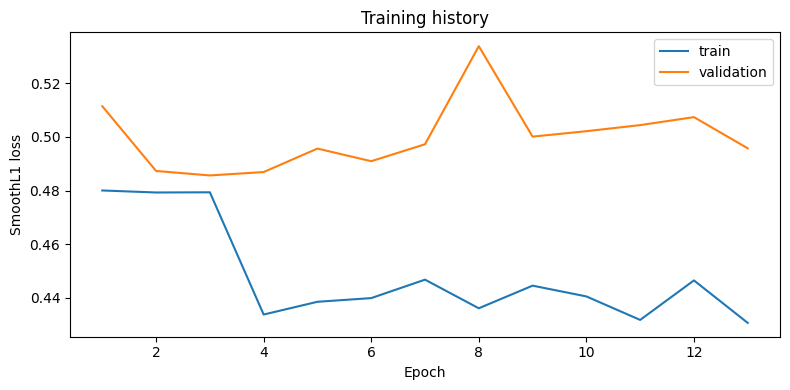

In [9]:
def make_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)


def train_forecaster(model, Xtr, ytr, Xv, yv, cfg: Config):
    train_loader = make_loader(Xtr, ytr, cfg.batch_size, True)
    val_loader = make_loader(Xv, yv, cfg.batch_size, False)

    opt = torch.optim.AdamW(
        model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
    )
    # outlier에 MSE보다 덜 민감한 robust loss
    loss_fn = nn.SmoothL1Loss(beta=0.5)

    best_state = None
    best_val = np.inf
    bad_epochs = 0
    history = []

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            pred, _, _, _ = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred, _, _, _ = model(xb)
                val_losses.append(loss_fn(pred, yb).item())

        tr = float(np.mean(train_losses))
        va = float(np.mean(val_losses))
        history.append((epoch, tr, va))

        if va < best_val - 1e-5:
            best_val = va
            best_state = deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch == 1 or epoch % 10 == 0:
            print(f'epoch={epoch:03d} train={tr:.5f} val={va:.5f}')

        if bad_epochs >= cfg.patience:
            print(f'early stopping at epoch {epoch}')
            break

    model.load_state_dict(best_state)
    return pd.DataFrame(history, columns=['epoch', 'train_loss', 'val_loss'])


set_seed(CFG.seed)
forecaster = MultiAssetLatentForecaster(
    n_assets=len(ASSET_NAMES),
    hidden_size=CFG.hidden_size,
    latent_size=CFG.latent_size,
).to(device)

history = train_forecaster(
    forecaster, X_train, y_train, X_val, y_val, CFG
)

plt.figure(figsize=(8, 4))
plt.plot(history['epoch'], history['train_loss'], label='train')
plt.plot(history['epoch'], history['val_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('SmoothL1 loss')
plt.title('Training history')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Out-of-Sample 예측 성능

,MAE,RMSE,R2,Directional_Accuracy,IC_Pearson
Model,,,,,
Zero Return,0.016992,0.026697,-0.007998,0.000000,NaN
AR-Ridge,0.017074,0.027040,-0.034086,0.511682,-0.063389
Cross-Asset Ridge,0.017809,0.026548,0.003254,0.528037,0.203146
Multi-Asset GRU,0.016284,0.025644,0.069973,0.621495,0.340684


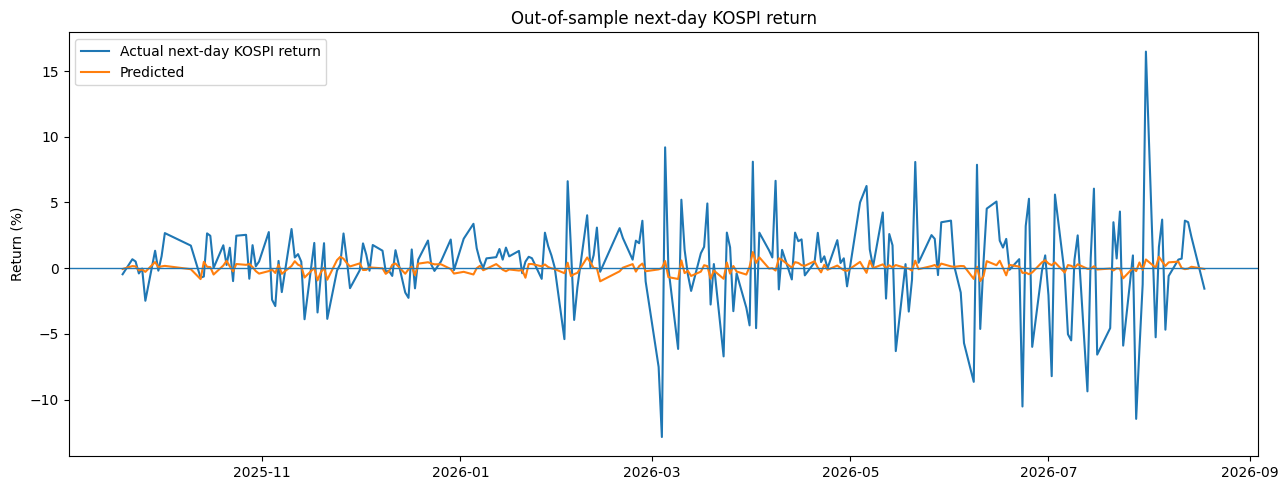

In [10]:
def model_inference(model, X, batch_size=512):
    model.eval()
    preds, latents, weights = [], [], []
    loader = DataLoader(
        torch.tensor(X, dtype=torch.float32),
        batch_size=batch_size,
        shuffle=False,
    )
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(device)
            pred, latent, w, _ = model(xb)
            preds.append(pred.cpu().numpy())
            latents.append(latent.cpu().numpy())
            weights.append(w.cpu().numpy())
    return np.concatenate(preds), np.concatenate(latents), np.concatenate(weights)


pred_test_z, latent_test, attn_test = model_inference(forecaster, X_test)
pred_test_raw = inverse_target(pred_test_z)

model_table = pd.concat([
    baseline_table,
    pd.DataFrame([
        forecast_metrics(y_test_raw, pred_test_raw, 'Multi-Asset GRU')
    ])
], ignore_index=True)

display(model_table.set_index('Model').round(6))

# return 단위는 decimal이므로 100을 곱해 %로 표시
plot_n = min(220, len(d_test))
plt.figure(figsize=(13, 5))
plt.plot(d_test[-plot_n:], y_test_raw[-plot_n:] * 100, label='Actual next-day KOSPI return')
plt.plot(d_test[-plot_n:], pred_test_raw[-plot_n:] * 100, label='Predicted')
plt.axhline(0, linewidth=1)
plt.ylabel('Return (%)')
plt.title('Out-of-sample next-day KOSPI return')
plt.legend()
plt.tight_layout()
plt.show()

### 해석 규칙

- `R² < 0`이면 test 구간에서는 상수 평균 예측보다도 제곱오차 기준으로 좋지 않을 수 있다.
- Directional Accuracy가 50%를 조금 넘는 정도라면 seed/기간/거래비용/통계적 유의성을 추가 검증해야 한다.
- IC가 양수라고 해서 수익성이나 경제적 유의성이 자동으로 보장되는 것은 아니다.
- 이 실험에서 중요한 것은 **그림이 실제값을 따라가는가**보다 OOS에서 baseline보다 반복적으로 개선되는가이다.

## 10. Latent representation과 asset attention

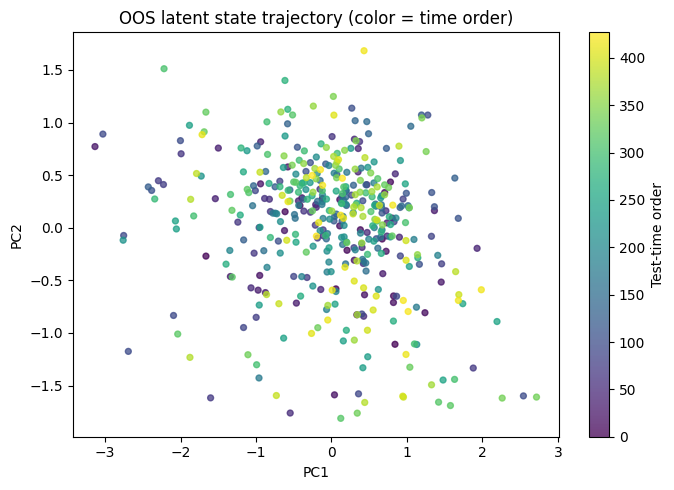

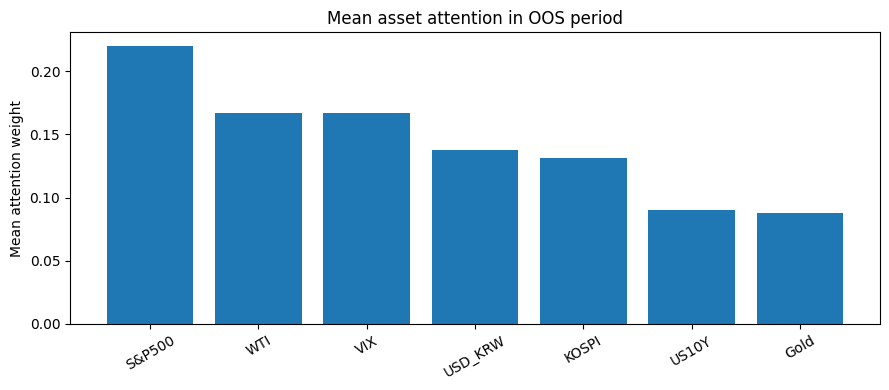

,mean_attention
S&P500,0.219728
WTI,0.166974
VIX,0.166962
USD_KRW,0.137952
KOSPI,0.130974
US10Y,0.089822
Gold,0.087588


In [11]:
# PCA는 train latent에서만 fit하고 test는 transform한다.
_, latent_train, attn_train = model_inference(forecaster, X_train)

pca = PCA(n_components=2)
pca.fit(latent_train)
latent_test_2d = pca.transform(latent_test)

plt.figure(figsize=(7, 5))
sc = plt.scatter(
    latent_test_2d[:, 0],
    latent_test_2d[:, 1],
    c=np.arange(len(latent_test_2d)),
    s=18,
    alpha=0.75,
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('OOS latent state trajectory (color = time order)')
plt.colorbar(sc, label='Test-time order')
plt.tight_layout()
plt.show()

mean_attention = pd.Series(attn_test.mean(axis=0), index=ASSET_NAMES).sort_values(ascending=False)
plt.figure(figsize=(9, 4))
plt.bar(mean_attention.index, mean_attention.values)
plt.xticks(rotation=30)
plt.ylabel('Mean attention weight')
plt.title('Mean asset attention in OOS period')
plt.tight_layout()
plt.show()

display(mean_attention.to_frame('mean_attention'))

**중요:** attention weight는 이 모델이 representation을 결합할 때 사용한 가중치이지, 경제적 인과효과나 SHAP과 같은 독립적인 feature attribution이 아니다. 따라서 “US10Y가 KOSPI를 몇 % 움직였다”와 같은 해석에 사용하면 안 된다.

# Part II. Latent Synchronization 기반 시장 충격 탐지

원래 실험의 흥미로운 아이디어는 “여러 자산이 latent space에서 동시에 비슷한 상태로 모이는 시점이 시장 충격과 관련될 수 있는가?”였다.

다만 독립 AE의 latent 내적 대신 다음 세 요소를 사용한다.

1. **Synchronization**: 같은 shared encoder가 만든 자산 latent들의 평균 absolute cosine similarity (같은 방향뿐 아니라 강한 역방향 결합도 포함)
2. **Latent displacement**: 전일 대비 latent state가 얼마나 크게 이동했는지
3. **Return intensity**: 그날 여러 자산의 표준화 수익률 절대값이 얼마나 큰지

각 요소는 train 구간의 평균과 표준편차로 표준화한 뒤 합쳐 `systemic_stress_score`를 만든다. 임계값도 train 구간에서만 정한다.

In [12]:
def build_asset_windows(zdf: pd.DataFrame, window: int):
    windows, end_dates = [], []
    arr = zdf.values.astype('float32')
    for end_i in range(window - 1, len(zdf)):
        w = arr[end_i - window + 1:end_i + 1]  # [T, A]
        windows.append(w.T)  # [A, T]
        end_dates.append(zdf.index[end_i])
    return np.asarray(windows, dtype='float32'), pd.DatetimeIndex(end_dates)


shock_windows, shock_dates = build_asset_windows(features_z, CFG.shock_window)
print('shock_windows:', shock_windows.shape)  # [date, asset, time]

shock_windows: (2829, 7, 20)


In [13]:
class SharedWindowAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


def train_shared_ae(train_windows, cfg: Config, seed: int):
    set_seed(seed)
    model = SharedWindowAutoencoder(
        input_dim=cfg.shock_window,
        hidden_dim=cfg.ae_hidden,
        latent_dim=cfg.ae_latent,
    ).to(device)

    # 모든 자산에 같은 encoder를 적용하므로 latent 좌표계가 공유된다.
    flat = train_windows.reshape(-1, cfg.shock_window)
    loader = DataLoader(
        torch.tensor(flat, dtype=torch.float32),
        batch_size=cfg.ae_batch_size,
        shuffle=True,
    )
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    model.train()
    for epoch in range(1, cfg.ae_epochs + 1):
        losses = []
        for xb in loader:
            xb = xb.to(device)
            opt.zero_grad(set_to_none=True)
            recon = model(xb)
            loss = loss_fn(recon, xb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(loss.item())
        if epoch == 1 or epoch % 10 == 0:
            print(f'[seed {seed}] ae epoch={epoch:03d} loss={np.mean(losses):.5f}')
    return model


def encode_windows(model, windows):
    # windows: [N, A, T]
    N, A, T = windows.shape
    flat = torch.tensor(windows.reshape(-1, T), dtype=torch.float32)
    loader = DataLoader(flat, batch_size=1024, shuffle=False)
    zs = []
    model.eval()
    with torch.no_grad():
        for xb in loader:
            z = model.encoder(xb.to(device)).cpu().numpy()
            zs.append(z)
    return np.concatenate(zs).reshape(N, A, -1)


def latent_score_components(z, windows):
    # z: [N, A, D]
    eps = 1e-8
    z_norm = z / (np.linalg.norm(z, axis=2, keepdims=True) + eps)

    # 평균 pairwise cosine similarity
    sim = np.einsum('nad,nbd->nab', z_norm, z_norm)
    A = z.shape[1]
    upper = np.triu_indices(A, k=1)
    sync = np.abs(sim[:, upper[0], upper[1]]).mean(axis=1)

    # latent state 이동량
    displacement = np.zeros(len(z), dtype=float)
    displacement[1:] = np.linalg.norm(z[1:] - z[:-1], axis=2).mean(axis=1)

    # window 마지막 날의 표준화된 자산 움직임 강도
    intensity = np.abs(windows[:, :, -1]).mean(axis=1)

    return sync, displacement, intensity

In [14]:
train_shock_mask = shock_dates <= TRAIN_END
val_shock_mask = (shock_dates > TRAIN_END) & (shock_dates <= VAL_END)
test_shock_mask = shock_dates > VAL_END

ensemble_components = []

for seed in CFG.ae_seeds:
    ae = train_shared_ae(shock_windows[train_shock_mask], CFG, seed)
    z_all = encode_windows(ae, shock_windows)
    ensemble_components.append(latent_score_components(z_all, shock_windows))

# seed에 따른 stochastic variation을 평균한다.
sync = np.mean([x[0] for x in ensemble_components], axis=0)
displacement = np.mean([x[1] for x in ensemble_components], axis=0)
intensity = np.mean([x[2] for x in ensemble_components], axis=0)


def train_standardize(x, mask):
    mu = np.mean(x[mask])
    sd = np.std(x[mask])
    sd = sd if sd > 1e-8 else 1.0
    return (x - mu) / sd, mu, sd

sync_z, sync_mu, sync_sd = train_standardize(sync, train_shock_mask)
disp_z, disp_mu, disp_sd = train_standardize(displacement, train_shock_mask)
intensity_z, int_mu, int_sd = train_standardize(intensity, train_shock_mask)

systemic_stress_score = sync_z + disp_z + intensity_z
score_threshold = np.quantile(
    systemic_stress_score[train_shock_mask], CFG.shock_quantile
)

signal = systemic_stress_score >= score_threshold

score_df = pd.DataFrame({
    'sync': sync,
    'displacement': displacement,
    'intensity': intensity,
    'sync_z': sync_z,
    'displacement_z': disp_z,
    'intensity_z': intensity_z,
    'systemic_stress_score': systemic_stress_score,
    'signal': signal,
}, index=shock_dates)

display(score_df.tail())
print('train-only score threshold =', round(float(score_threshold), 4))

[seed 11] ae epoch=001 loss=0.99522
[seed 11] ae epoch=010 loss=0.60161
[seed 11] ae epoch=020 loss=0.56354
[seed 11] ae epoch=030 loss=0.54699
[seed 11] ae epoch=040 loss=0.53531
[seed 11] ae epoch=050 loss=0.52517
[seed 23] ae epoch=001 loss=0.99269
[seed 23] ae epoch=010 loss=0.61621
[seed 23] ae epoch=020 loss=0.56970
[seed 23] ae epoch=030 loss=0.55144
[seed 23] ae epoch=040 loss=0.54058
[seed 23] ae epoch=050 loss=0.53262
[seed 37] ae epoch=001 loss=0.99453
[seed 37] ae epoch=010 loss=0.60862
[seed 37] ae epoch=020 loss=0.56723
[seed 37] ae epoch=030 loss=0.54957
[seed 37] ae epoch=040 loss=0.53688
[seed 37] ae epoch=050 loss=0.52654


,sync,displacement,intensity,sync_z,displacement_z,intensity_z,systemic_stress_score,signal
2026-08-11,0.355413,7.586482,0.520540,-1.404155,1.917701,-0.358526,0.155021,False
2026-08-12,0.365649,7.341168,0.795213,-1.164289,1.782063,0.310018,0.927791,False
2026-08-13,0.437068,7.397257,1.033165,0.509257,1.813075,0.889184,3.211517,True
2026-08-14,0.377789,8.140066,0.674105,-0.879817,2.223788,0.015245,1.359215,False
2026-08-18,0.368415,8.302277,0.819740,-1.099471,2.313477,0.369715,1.583721,False


train-only score threshold = 2.7068


## 11. 충격 신호를 객관적인 label과 비교

시각적으로 “위기처럼 보인다”라고 판단하는 대신 KOSPI의 큰 절대수익률을 간단한 shock label로 정의한다.

- shock magnitude threshold는 train 기간 KOSPI `|return|`의 95% quantile
- **same-day detection**: score(t)와 shock(t)의 관계
- **early warning**: score(t)와 shock(t+1)의 관계

early warning이 더 어려운 문제이며, 실제 예측적 가치가 있다면 이 쪽에서 확인되어야 한다.

In [15]:
kospi_ret = features[TARGET]
train_kospi_abs = kospi_ret.loc[:TRAIN_END].abs()
kospi_shock_threshold = np.quantile(train_kospi_abs, CFG.shock_quantile)

# shock_dates에 맞춰 현재/다음 거래일 KOSPI return을 정렬한다.
same_day_ret = kospi_ret.reindex(shock_dates)
next_day_ret = kospi_ret.shift(-1).reindex(shock_dates)

same_day_shock = (same_day_ret.abs() >= kospi_shock_threshold).astype(float)
next_day_shock = (next_day_ret.abs() >= kospi_shock_threshold).astype(float)


def binary_eval(y_true, continuous_score, hard_signal, name):
    valid = np.isfinite(y_true) & np.isfinite(continuous_score)
    yt = np.asarray(y_true)[valid].astype(int)
    sc = np.asarray(continuous_score)[valid]
    hs = np.asarray(hard_signal)[valid].astype(int)

    out = {
        'Task': name,
        'N': len(yt),
        'Shock_Rate': yt.mean() if len(yt) else np.nan,
        'Precision': precision_score(yt, hs, zero_division=0),
        'Recall': recall_score(yt, hs, zero_division=0),
        'F1': f1_score(yt, hs, zero_division=0),
    }
    if len(np.unique(yt)) == 2:
        out['AUROC'] = roc_auc_score(yt, sc)
    else:
        out['AUROC'] = np.nan
    return out


test_idx = test_shock_mask
same_res = binary_eval(
    same_day_shock.values[test_idx],
    systemic_stress_score[test_idx],
    signal[test_idx],
    'Same-day shock detection',
)
next_res = binary_eval(
    next_day_shock.values[test_idx],
    systemic_stress_score[test_idx],
    signal[test_idx],
    'Next-day shock early warning',
)

shock_eval = pd.DataFrame([same_res, next_res]).set_index('Task')
display(shock_eval.round(4))

,N,Shock_Rate,Precision,Recall,F1,AUROC
Task,,,,,,
Same-day shock detection,428,0.2593,0.6316,0.4324,0.5134,0.8214
Next-day shock early warning,428,0.2570,0.4342,0.3000,0.3548,0.6966


## 12. Shock-score ablation

In [16]:
def test_auc(score, y, mask):
    yy = np.asarray(y)[mask]
    ss = np.asarray(score)[mask]
    valid = np.isfinite(yy) & np.isfinite(ss)
    yy, ss = yy[valid].astype(int), ss[valid]
    if len(np.unique(yy)) < 2:
        return np.nan
    return roc_auc_score(yy, ss)


ablation = pd.DataFrame({
    'Score': ['Synchronization only', 'Latent displacement only', 'Return intensity only', 'Combined'],
    'NextDay_Shock_AUROC': [
        test_auc(sync_z, next_day_shock.values, test_idx),
        test_auc(disp_z, next_day_shock.values, test_idx),
        test_auc(intensity_z, next_day_shock.values, test_idx),
        test_auc(systemic_stress_score, next_day_shock.values, test_idx),
    ]
}).set_index('Score')

display(ablation.round(4))

,NextDay_Shock_AUROC
Score,
Synchronization only,0.4340
Latent displacement only,0.6982
Return intensity only,0.6703
Combined,0.6966


## 13. 충격 시점 시각화

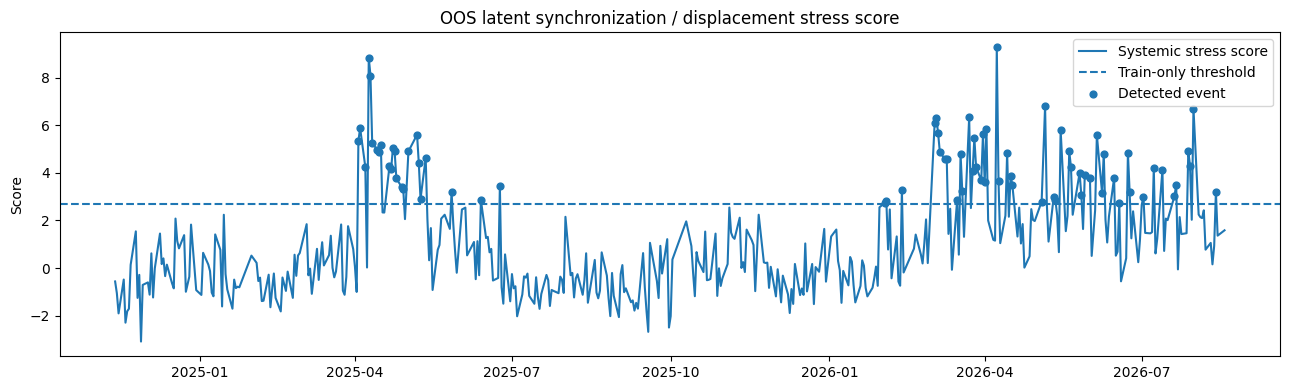

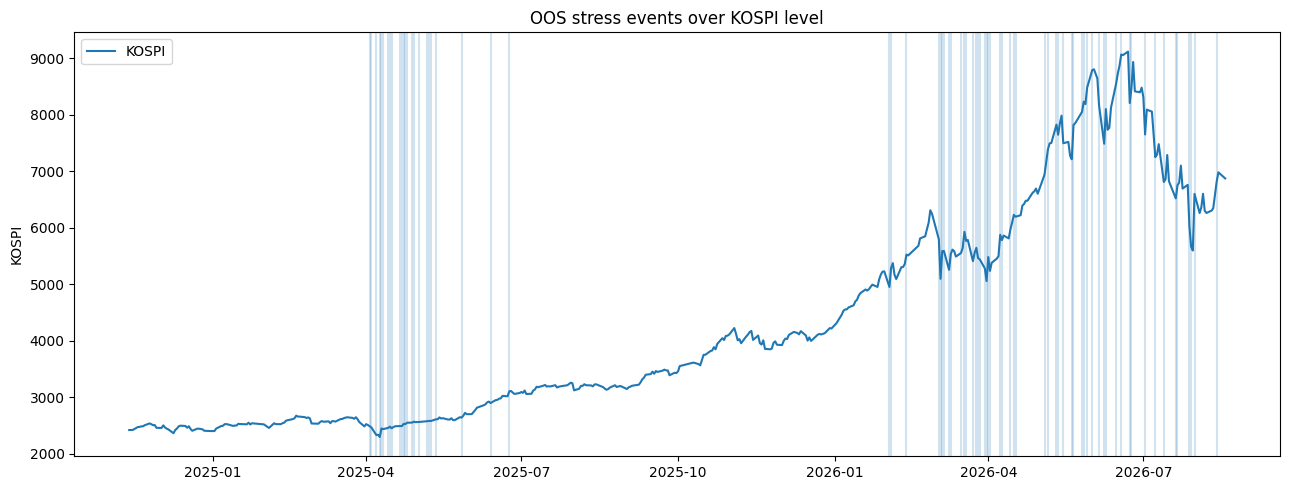

In [17]:
test_score = score_df.loc[score_df.index > VAL_END]

plt.figure(figsize=(13, 4))
plt.plot(test_score.index, test_score['systemic_stress_score'], label='Systemic stress score')
plt.axhline(score_threshold, linestyle='--', label='Train-only threshold')
plt.scatter(
    test_score.index[test_score['signal']],
    test_score.loc[test_score['signal'], 'systemic_stress_score'],
    marker='o',
    s=24,
    label='Detected event',
)
plt.ylabel('Score')
plt.title('OOS latent synchronization / displacement stress score')
plt.legend()
plt.tight_layout()
plt.show()

# 같은 signal을 KOSPI level 위에 표시하되, 이는 "예측 성공"을 의미하지 않는다.
kospi_level = prices['KOSPI'].reindex(test_score.index).ffill()
plt.figure(figsize=(13, 5))
plt.plot(kospi_level.index, kospi_level.values, label='KOSPI')
for dt in test_score.index[test_score['signal']]:
    plt.axvline(dt, alpha=0.20)
plt.title('OOS stress events over KOSPI level')
plt.ylabel('KOSPI')
plt.legend()
plt.tight_layout()
plt.show()

## 14. Event-level sanity check

signal이 난 다음 날 실제 변동이 평균적으로 더 컸는지 단순하게 비교한다. 이 값은 거래전략 수익률이 아니라 **신호의 조건부 위험 집중도**를 보는 진단이다.

In [18]:
test_dates_score = shock_dates[test_idx]
test_signal = signal[test_idx]
test_next_abs = next_day_ret.values[test_idx]
test_next_abs = np.abs(test_next_abs)

valid = np.isfinite(test_next_abs)
all_mean = np.mean(test_next_abs[valid])
signal_mean = np.mean(test_next_abs[valid & test_signal]) if np.any(valid & test_signal) else np.nan

summary_event = pd.DataFrame({
    'Statistic': [
        'Mean next-day |KOSPI return|: all test days',
        'Mean next-day |KOSPI return|: signaled days',
        'Number of test signals',
    ],
    'Value': [all_mean, signal_mean, int(np.sum(test_signal))]
})
display(summary_event)

,Statistic,Value
0,Mean next-day |KOSPI return|: all test days,0.016969
1,Mean next-day |KOSPI return|: signaled days,0.025765
2,Number of test signals,76.000000


# 15. 결과를 과장하지 않는 자동 요약

아래 셀은 실행 결과를 바탕으로 최소한의 결론만 출력한다. 특정 방향의 결과를 미리 정해두지 않는다.

In [19]:
metrics_idx = model_table.set_index('Model')

best_baseline_rmse = metrics_idx.loc[
    ['Zero Return', 'AR-Ridge', 'Cross-Asset Ridge'], 'RMSE'
].min()
dl_rmse = metrics_idx.loc['Multi-Asset GRU', 'RMSE']

print('=== Forecasting ===')
if dl_rmse < best_baseline_rmse:
    improvement = 100 * (best_baseline_rmse - dl_rmse) / best_baseline_rmse
    print(f'Multi-Asset GRU beats the best baseline RMSE by {improvement:.2f}% on this OOS split.')
else:
    gap = 100 * (dl_rmse - best_baseline_rmse) / best_baseline_rmse
    print(f'Multi-Asset GRU does NOT beat the best baseline RMSE; gap = {gap:.2f}%.')

print('\n=== Latent shock score ===')
auc_next = shock_eval.loc['Next-day shock early warning', 'AUROC']
if np.isfinite(auc_next):
    if auc_next >= 0.60:
        print(f'Next-day shock AUROC = {auc_next:.3f}: potentially useful signal, but walk-forward/seed robustness is still required.')
    elif auc_next > 0.50:
        print(f'Next-day shock AUROC = {auc_next:.3f}: weak predictive ordering; evidence is not yet strong.')
    else:
        print(f'Next-day shock AUROC = {auc_next:.3f}: no useful next-day ranking evidence on this test split.')
else:
    print('Next-day AUROC could not be computed because the test label has only one class.')

print('\nInterpretation rule: same-day detection can describe stress, but only next-day evaluation tests early-warning value.')

=== Forecasting ===
Multi-Asset GRU beats the best baseline RMSE by 3.40% on this OOS split.

=== Latent shock score ===
Next-day shock AUROC = 0.697: potentially useful signal, but walk-forward/seed robustness is still required.

Interpretation rule: same-day detection can describe stress, but only next-day evaluation tests early-warning value.


# 16. 연구 한계

1. **일별 timestamp 정렬**  
   미국장·한국장·선물·FX의 실제 관측 가능 시각을 완전히 반영한 데이터셋은 아니다. 다음 단계에서는 timezone-aware close/open alignment가 필요하다.

2. **shock label의 단순성**  
   `|KOSPI return|` 상위 5%는 객관적이지만 시장 충격의 모든 의미를 담지 못한다. drawdown, VIX jump, liquidity stress, cross-market breadth 등을 함께 볼 수 있다.

3. **representation은 인과가 아니다**  
   PCA, attention, cosine synchronization은 latent 구조를 보여줄 뿐 경제적 인과관계를 증명하지 않는다.

4. **한 번의 split만으로는 부족하다**  
   최종 연구에서는 expanding/rolling walk-forward, 여러 seed, regime별 평가가 필요하다.

5. **threshold stability**  
   train 95% quantile이라는 사전 규칙을 사용했지만 시기에 따라 base rate가 달라질 수 있다. calibration과 conformal threshold를 검토할 수 있다.

6. **딥러닝이 baseline보다 못할 수 있다**  
   이는 실패가 아니라 중요한 연구 결과다. 금융 시계열에서는 복잡한 representation이 반드시 다음날 수익률 예측력으로 이어지지 않는다.

# 17. 다음 단계

세미나 이후 연구를 이어간다면 다음 순서가 가장 자연스럽다.

### A. 검증 고도화
- expanding walk-forward refit
- 5~10 seeds 안정성
- bootstrap confidence interval
- 상승장/하락장/고변동성 regime 분리

### B. latent interaction 고도화
- shared AE → contrastive/Siamese temporal encoder
- 단순 cosine → lead-lag directed similarity
- NRI/GNN으로 동적 자산 interaction graph 추정

### C. shock detection → risk forecasting
- `P(shock_{t+1} | state_t)` binary head
- conditional quantile / VaR / ES head
- latent state에 따라 tail distribution이 달라지는 state-dependent risk model

### D. 실시간성
- 각 시장의 실제 close timestamp 기준 lag map
- 하루 단위 batch가 아니라 신규 데이터 도착 시 causal update

이렇게 발전시키면 최초의 “hidden state에 경제적 의미가 있는가?”라는 질문을 **예측 → representation → 충격 탐지 → 위험 예측**의 검증 가능한 연구 흐름으로 연결할 수 있다.